In [1]:
import sys
import yaml
import argparse
import numpy as np
import igraph as ig
import networkx as nx
import matplotlib.pyplot as plt
from scipy.linalg import expm
from dataclasses import asdict
from qlgates.constants import *
from qlgates.config import Config
from qlgates.run_dynamics import propagate_state, build_unitary, bell_state
from qlgates.cldyn import initial_state_z_up, exact_eigen, transverse_field_ising, propagate_state_classical, transverse_ising_trotter, kron_N, exact_unitary
from qlgates.qlgraphs import qldit, cart_qldit, compute_eigen_decomposition
from qlgates.helpers import build_local_operators, expectation

In [2]:
print(sys.executable)   # should show your conda env path, not system python

"""Load YAML and merge into Config dataclass."""
with open("../configs/run1.yaml") as f:
    overrides = yaml.safe_load(f)  # plain dict from YAML

# These are computed in __post_init__, never let YAML set them
overrides.pop("l", None)
overrides.pop("lp", None)

# Create Config instance with merged parameters
cfg = Config(**overrides)

print("=" * 40)
print("Simulation parameters")
print("=" * 40)

for key, value in asdict(cfg).items():
    print(f"  {key}: {value}")
print("=" * 40)

/Users/sahadebadrita/opt/anaconda3/envs/graphs/bin/python
Simulation parameters
  debug: False
  n: 16
  k: 12
  d: 1
  l: 2
  lp: 1
  coupling: True
  periodic: False
  full: False
  NQL: 4
  CartPdt: True
  model: transverse
  timesteps: 100
  deltat: 0.1
  J: -1.0
  h: 0.5


Exact diagonalization

0 0.0
1 0.1
2 0.2
3 0.30000000000000004
4 0.4
5 0.5
6 0.6000000000000001
7 0.7000000000000001
8 0.8
9 0.9
10 1.0
11 1.1
12 1.2000000000000002
13 1.3
14 1.4000000000000001
15 1.5
16 1.6
17 1.7000000000000002
18 1.8
19 1.9000000000000001
20 2.0
21 2.1
22 2.2
23 2.3000000000000003
24 2.4000000000000004
25 2.5
26 2.6
27 2.7
28 2.8000000000000003
29 2.9000000000000004
30 3.0
31 3.1
32 3.2
33 3.3000000000000003
34 3.4000000000000004
35 3.5
36 3.6
37 3.7
38 3.8000000000000003
39 3.9000000000000004
40 4.0
41 4.1000000000000005
42 4.2
43 4.3
44 4.4
45 4.5
46 4.6000000000000005
47 4.7
48 4.800000000000001
49 4.9
50 5.0
51 5.1000000000000005
52 5.2
53 5.300000000000001
54 5.4
55 5.5
56 5.6000000000000005
57 5.7
58 5.800000000000001
59 5.9
60 6.0
61 6.1000000000000005
62 6.2
63 6.300000000000001
64 6.4
65 6.5
66 6.6000000000000005
67 6.7
68 6.800000000000001
69 6.9
70 7.0
71 7.1000000000000005
72 7.2
73 7.300000000000001
74 7.4
75 7.5
76 7.6000000000000005
77 7.7
78 7.800000000000001
79 7.9
80 8.0

Text(0.5, 1.0, '$\\bar{M}_{z}$ vs h/|J|')

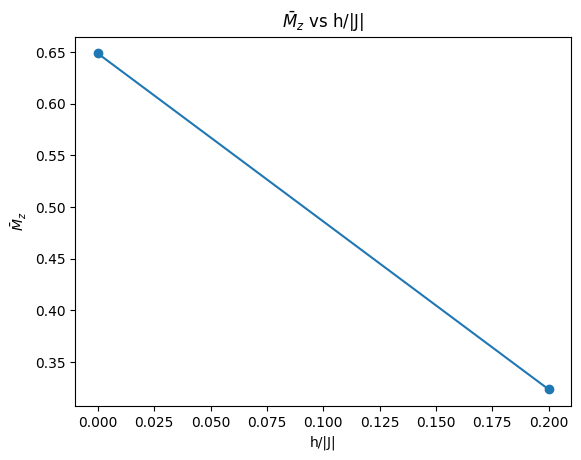

In [3]:
cfg.NQL = 10
times = np.arange(0, cfg.timesteps * cfg.deltat, cfg.deltat)
psi0 = initial_state_z_up(cfg.NQL)

for j in range(cfg.NQL):
    mz = build_local_operators(Z,I2,cfg.NQL)

M_eq_exact = []  # Store equilibrium values for each site
ratios = []  # Store ratios for each site

#for h in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:
for h in [0.0, 0.2]:
    #Create Hamiltonian and compute eigenvalues/eigenvectors
    H = transverse_field_ising(cfg.NQL, h, cfg.J)
    #print(psi0.shape, H.shape)

    evals, evecs = np.linalg.eigh(H)
    #print(np.linalg.norm(evecs.conj().T-np.linalg.inv(evecs),'fro'))
    coeffs = evecs.conj().T @ psi0
    psit = np.empty((len(psi0), len(times)), dtype=complex)

    for i, t in enumerate(times):
        print(i,t)
        phases = np.exp(-1j * evals * t)
        psit[:, i] = evecs @ (phases * coeffs)

    # #print(psit.shape)

    expectation_mz_exact = np.empty((psit.shape[1], cfg.NQL+2))  # +2 for time steps and mean expectation
    for j in range(len(mz)):
        expectation_mz_exact[:,j] = expectation(psit, mz[j])
    expectation_mz_exact[:,-1] = np.arange(cfg.timesteps)  # Add time steps as the last column
    expectation_mz_exact[:,-2] = np.mean(expectation_mz_exact[:,:-2], axis=1)  # Add mean expectation values as the second-to-last column
    M_eq_exact.append(np.mean(np.abs(expectation_mz_exact[int(0.0*cfg.timesteps):,-2])))  # Mean of the absolute values of the mean expectation values in the last 20% of time steps
    ratios.append(abs(h/cfg.J))  # Ratio of the equilibrium value at this h to the equilibrium value at the smallest h

print(M_eq_exact)
print(ratios)
plt.plot(ratios, M_eq_exact, marker='o')
plt.xlabel('h/|J|')
plt.ylabel(r'$\bar{M}_{z}$')
plt.title(r'$\bar{M}_{z}$ vs h/|J|')

Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
[1.0, 0.9599540396583525, 0.7979234527664292, 0.563825808741033, 0.2801478065231549, 0.0906933326746573, 0.057880183468789884, 0.06582047981204396, 0.06746256700549959, 0.0638296513073847, 0.06101438686418494]
[0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]


Text(0.5, 1.0, '$\\bar{M}_{z}$ vs h/|J|')

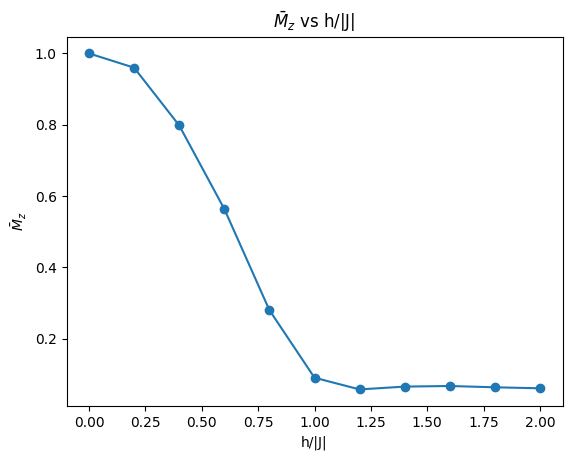

In [12]:
times = np.arange(0, cfg.timesteps * cfg.deltat, cfg.deltat)
psi0 = initial_state_z_up(cfg.NQL)

M_eq_exact = []  # Store equilibrium values for each site
ratios = []  # Store ratios for each site

for cfg.h in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:
#for h in [0.0, 0.2]:
    #Create Hamiltonian and compute eigenvalues/eigenvectors
    H = transverse_field_ising(cfg.NQL, cfg.J, cfg.h)
    #print(psi0.shape, H.shape)

    psit = exact_eigen(H, psi0, times)
    #print(psit.shape)

    expectation_mz_exact = np.empty((psit.shape[1], cfg.NQL+2))  # +2 for time steps and mean expectation
    for j in range(len(mz)):
        expectation_mz_exact[:,j] = expectation(psit, mz[j])
    expectation_mz_exact[:,-1] = np.arange(cfg.timesteps)  # Add time steps as the last column
    expectation_mz_exact[:,-2] = np.mean(expectation_mz_exact[:,:-2], axis=1)  # Add mean expectation values as the second-to-last column
    M_eq_exact.append(np.mean(np.abs(expectation_mz_exact[int(0.8*cfg.timesteps):,-2])))  # Mean of the absolute values of the mean expectation values in the last 20% of time steps
    ratios.append(abs(cfg.h/cfg.J))  # Ratio of the equilibrium value at this h to the equilibrium value at the smallest h

print(M_eq_exact)
print(ratios)
plt.plot(ratios, M_eq_exact, marker='o')
plt.xlabel('h/|J|')
plt.ylabel(r'$\bar{M}_{z}$')
plt.title(r'$\bar{M}_{z}$ vs h/|J|')

[1.0000000000000144, 0.9725150202322971, 0.8489667355666186, 0.6298758310648743, 0.34420593977088787, 0.10081366788741356, 0.09701507182935216, 0.09475120142328083, 0.09203634246132593, 0.09041374557220613, 0.08963636449993002]
[0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]


Text(0.5, 1.0, '$\\bar{M}_{z}$ vs h/|J|')

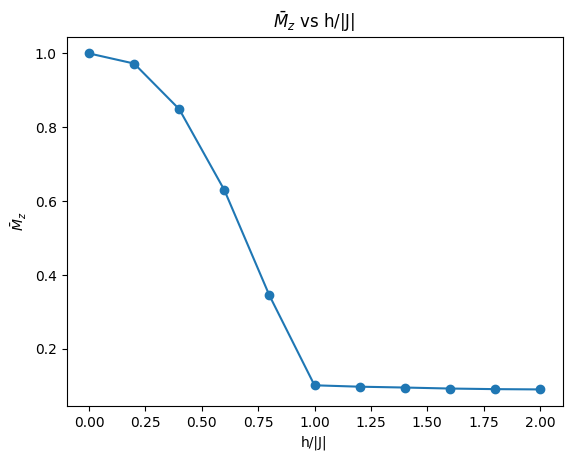

In [4]:
cfg.NQL = 10

times = np.arange(0, cfg.timesteps * cfg.deltat, cfg.deltat)
psi0 = initial_state_z_up(cfg.NQL)

for j in range(cfg.NQL):
    mz = build_local_operators(Z,I2,cfg.NQL)

M_eq_exact = []  # Store equilibrium values for each site
ratios = []  # Store ratios for each site

for cfg.h in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:
#for h in [0.0, 0.2]:
    #Create Hamiltonian and compute eigenvalues/eigenvectors
    #H = transverse_field_ising(cfg.NQL, cfg.h, cfg.J)
    #print(psi0.shape, H.shape)

    psit = propagate_state_classical(cfg, psi0)
    #print(psit.shape)

    expectation_mz_exact = np.empty((psit.shape[1], cfg.NQL+2))  # +2 for time steps and mean expectation
    for j in range(len(mz)):
        expectation_mz_exact[:,j] = expectation(psit, mz[j])
    expectation_mz_exact[:,-1] = np.arange(cfg.timesteps)  # Add time steps as the last column
    expectation_mz_exact[:,-2] = np.mean(expectation_mz_exact[:,:-2], axis=1)  # Add mean expectation values as the second-to-last column
    M_eq_exact.append(np.mean(np.abs(expectation_mz_exact[int(0.0*cfg.timesteps):,-2])))  # Mean of the absolute values of the mean expectation values in the last 20% of time steps
    ratios.append(abs(cfg.h/cfg.J))  # Ratio of the equilibrium value at this h to the equilibrium value at the smallest h

print(M_eq_exact)
print(ratios)
plt.plot(ratios, M_eq_exact, marker='o')
plt.xlabel('h/|J|')
plt.ylabel(r'$\bar{M}_{z}$')
plt.title(r'$\bar{M}_{z}$ vs h/|J|')

In [4]:
transverse_field_ising(2, 1.0, cfg.J).real

array([[ 1., -1., -1.,  0.],
       [-1., -1.,  0., -1.],
       [-1.,  0., -1., -1.],
       [ 0., -1., -1.,  1.]])

In [ ]:
times = np.arange(0, cfg.timesteps * cfg.deltat, cfg.deltat)
psi0 = initial_state_z_up(cfg.NQL)

for j in range(cfg.NQL):
    mz = build_local_operators(Z,I2,cfg.NQL)

M_eq_exact = []  # Store equilibrium values for each site
M_eq_trotter = []  # Store trotter values for each site
ratios = []  # Store ratios for each site

#for h in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:
#for h in [2.0]:
#Create Hamiltonian and compute eigenvalues/eigenvectors
H = transverse_field_ising(cfg.NQL, h, cfg.J)
#print(psi0.shape, H.shape)
print(psi0)
evals, evecs = np.linalg.eigh(H)
coeffs = evecs.conj().T @ psi0
psit_exact = np.empty((len(psi0), len(times)), dtype=complex)

for i, t in enumerate(times):
    #print(f"Time step {i+1}/{len(times)}: t={t:.2f}")
    phases = np.exp(-1j * evals * t)
    psit_exact[:, i] = evecs @ (phases * coeffs)

print(psi0)
#print(psit_exact.shape)
psit_trotter = propagate_state_classical(cfg, psi0)

exact_fidelity = []
trotter_fidelity = []
trotter_exact_overlap = []

for step in range(cfg.timesteps):
    exact_fidelity.append(np.abs(np.vdot(psit_exact[:,step], psi0))**2)
    trotter_fidelity.append(np.abs(np.vdot(psit_trotter[:,step], psi0))**2)
    trotter_exact_overlap.append(np.abs(np.vdot(psit_trotter[:,step], psit_exact[:,step]))**2)


plt.plot(times, exact_fidelity, c='blue', marker='o', label='Exact')
plt.plot(times, trotter_fidelity, c='red', marker='x', label='Trotter')
plt.plot(times, trotter_exact_overlap, c='green', label='Trotter-Exact')
plt.xlabel('time')
plt.ylabel(r'Fidelity')
plt.legend()

[ 0.99251873+0.09983342j  0.        -0.04966733j  0.        -0.04966733j
 -0.00248544+0.j        ]
[ 1.00000000e+00+0.j -1.38777878e-16+0.j -1.66533454e-16+0.j
 -5.55111512e-17+0.j]


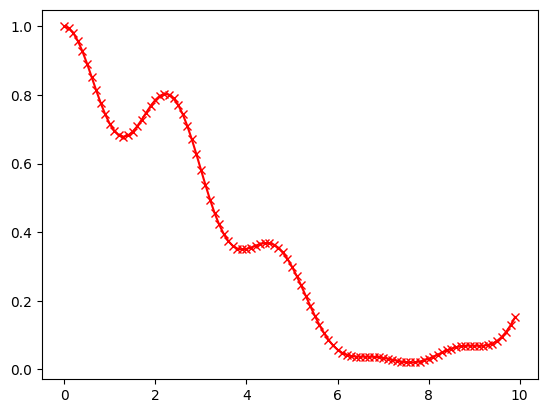

In [29]:
psi0_test = initial_state_z_up(cfg.NQL)
Ug = transverse_ising_trotter(cfg.NQL, cfg.J, cfg.h, cfg.deltat)
psit_trotter_test = propagate_state_classical(cfg, psi0_test)
trotter_fidelity_test = []
for step in range(cfg.timesteps):
    trotter_fidelity_test.append(np.abs(np.vdot(psit_trotter_test[:,step], psi0_test))**2)
print(Ug@psi0_test)
print(psit_exact[:,0])
plt.plot(times, trotter_fidelity_test, c='red', marker='x', label='Trotter')


In [4]:
cfg.NQL = 2
dim = 2 ** cfg.NQL
H = np.zeros((dim, dim), dtype=complex)
# --- Ising ZZ term ---
for i in range(cfg.NQL - 1):
    ops = [I2] * cfg.NQL
    ops[i]     = Z
    ops[i + 1] = Z
    print(cfg.J * kron_N(ops))
    H += cfg.J * kron_N(ops)


[[-1.+0.j -0.+0.j -0.+0.j -0.+0.j]
 [-0.+0.j  1.-0.j -0.+0.j  0.-0.j]
 [-0.+0.j -0.+0.j  1.-0.j  0.-0.j]
 [-0.+0.j  0.-0.j  0.-0.j -1.+0.j]]


In [8]:
# --- Transverse field X term ---
for i in range(cfg.NQL):
    ops = [I2] * cfg.NQL
    ops[i] = X
    print(cfg.h * kron_N(ops))
    H += cfg.h * kron_N(ops)

[[0. +0.j 0. +0.j 0.5+0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0.5+0.j 0. +0.j 0. +0.j]]
[[0. +0.j 0.5+0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0.5+0.j 0. +0.j]]


In [9]:
print(H)

[[-1. +0.j  0.5+0.j  0.5+0.j  0. +0.j]
 [ 0.5+0.j  1. +0.j  0. +0.j  0.5+0.j]
 [ 0.5+0.j  0. +0.j  1. +0.j  0.5+0.j]
 [ 0. +0.j  0.5+0.j  0.5+0.j -1. +0.j]]


In [16]:
U_exact = expm(-1j * H * cfg.deltat)
print(U_exact)

[[ 9.92510410e-01+9.97502082e-02j -4.49139220e-19-4.98334999e-02j
  -9.27501077e-20-4.98334999e-02j -2.49375486e-03-8.32084028e-05j]
 [-9.40206571e-20-4.98334999e-02j  9.92510410e-01-9.97502082e-02j
  -2.49375486e-03+8.32084028e-05j -4.33680869e-19-4.98334999e-02j]
 [-8.55503277e-20-4.98334999e-02j -2.49375486e-03+8.32084028e-05j
   9.92510410e-01-9.97502082e-02j  0.00000000e+00-4.98334999e-02j]
 [-2.49375486e-03-8.32084028e-05j  8.19157014e-20-4.98334999e-02j
   1.75249955e-19-4.98334999e-02j  9.92510410e-01+9.97502082e-02j]]


In [17]:
evals, evecs = np.linalg.eigh(H)
U_eigen = evecs @ np.diag(np.exp(-1j * evals * cfg.deltat)) @ evecs.conj().T
print(U_eigen)

[[ 9.92510410e-01+9.97502082e-02j -1.38777878e-16-4.98334999e-02j
  -1.66533454e-16-4.98334999e-02j -2.49375486e-03-8.32084028e-05j]
 [-1.38777878e-16-4.98334999e-02j  9.92510410e-01-9.97502082e-02j
  -2.49375486e-03+8.32084028e-05j  1.66533454e-16-4.98334999e-02j]
 [-1.38777878e-16-4.98334999e-02j -2.49375486e-03+8.32084028e-05j
   9.92510410e-01-9.97502082e-02j -2.77555756e-16-4.98334999e-02j]
 [-2.49375486e-03-8.32084028e-05j  1.66533454e-16-4.98334999e-02j
  -2.77555756e-16-4.98334999e-02j  9.92510410e-01+9.97502082e-02j]]


In [28]:
Ug = transverse_ising_trotter(cfg.NQL, cfg.J, cfg.h,0.01)

In [29]:
print(np.linalg.norm(Ug - U_exact,'fro'))
print(np.linalg.norm(Ug - U_eigen,'fro'))
print(np.linalg.norm(U_exact - U_eigen,'fro'))

0.22033023262023982
0.2203302326202396
1.9732447942248897e-15


In [8]:
H = transverse_field_ising(cfg.NQL, cfg.h, cfg.J)
U_exact = expm(-1j * H * cfg.deltat)

H2,U_exact2 = exact_unitary(cfg.NQL, cfg.J, cfg.h, cfg.deltat)

print(np.linalg.norm(U_exact-U_exact2,'fro'))
print(np.linalg.norm(H-H2,'fro'))

19.94254619057002
209.22714928995234


In [4]:
dim = 2 ** cfg.NQL

Hamiltonian_1 = np.zeros((dim, dim), dtype=complex)

# ZZ terms
for i in range(cfg.NQL - 1):
    ops = [I2] * cfg.NQL
    ops[i]     = Z
    ops[i + 1] = Z
    ZZi = ops[0]
    for op in ops[1:]:
        ZZi = np.kron(ZZi, op)
    Hamiltonian_1 += cfg.J * ZZi

# X terms
for i in range(cfg.NQL):
    ops = [I2] * cfg.NQL
    ops[i] = X
    Xi = ops[0]
    for op in ops[1:]:
        Xi = np.kron(Xi, op)
    Hamiltonian_1 += cfg.h * Xi

In [5]:
dim = 2**cfg.NQL
Hamiltonian_2 = np.zeros((dim, dim), dtype=complex)
sx = np.array([[0, 1],
               [1, 0]], dtype=complex)

sz = np.array([[1,  0],
               [0, -1]], dtype=complex)

id2 = np.eye(2, dtype=complex)

# --- Ising ZZ term ---
for i in range(cfg.NQL - 1):
    ops = [I2] * cfg.NQL
    ops[i]     = Z
    ops[i + 1] = Z
    Hamiltonian_2 += cfg.J * kron_N(ops)

# --- Transverse field X term ---
for i in range(cfg.NQL):
    ops = [I2] * cfg.NQL
    ops[i] = X
    Hamiltonian_2 += cfg.h * kron_N(ops)

In [7]:
print(np.linalg.norm(Hamiltonian_2-Hamiltonian_1,'fro'))
print(np.allclose(Hamiltonian_1, Hamiltonian_2))
print(np.max(np.abs(Hamiltonian_1 - Hamiltonian_2)))

0.0
True
0.0


In [20]:
U1 = expm(-1j*Hamiltonian_1*cfg.deltat)
U2 = expm(-1j*Hamiltonian_2*cfg.deltat)

print(np.linalg.norm(U2-U1,'fro'))

0.0


In [21]:
print(cfg.NQL)

10


In [24]:
Hamiltonian_3, U3 = exact_unitary(cfg.NQL,cfg.J,cfg.h,cfg.deltat)
print(np.linalg.norm(Hamiltonian_2-Hamiltonian_3,'fro'))
print(np.linalg.norm(Hamiltonian_3-Hamiltonian_1,'fro'))

0.0
0.0


In [17]:
from scipy.linalg import expm

for cfg.deltat in [0.1, 0.01, 0.001]:
    H = transverse_field_ising(cfg.NQL, cfg.J, cfg.h)
    U_exact = expm(-1j * H * cfg.deltat)
    U_trot = transverse_ising_trotter(cfg.NQL, cfg.J, cfg.h, cfg.deltat)

    evals, evecs = np.linalg.eigh(H)
    U_eigen = evecs @ np.diag(np.exp(-1j * evals * cfg.deltat)) @ evecs.conj().T

    err_expm_eigen = np.max(np.abs(U_exact - U_eigen))
    err_trot_exact = np.max(np.abs(U_trot - U_exact))

    print(f"deltat={cfg.deltat:.4f}  "
          f"|expm-eigen|={err_expm_eigen:.3e}  "
          f"|trot-exact|={err_trot_exact:.3e}  "
          f"ratio/dt^3={err_trot_exact/cfg.deltat**3:.3e}")

deltat=0.1000  |expm-eigen|=4.493e-15  |trot-exact|=1.029e-02  ratio/dt^3=1.029e+01
deltat=0.0100  |expm-eigen|=1.333e-15  |trot-exact|=1.198e-05  ratio/dt^3=1.198e+01
deltat=0.0010  |expm-eigen|=1.221e-15  |trot-exact|=1.200e-08  ratio/dt^3=1.200e+01


Config(debug=False, n=16, k=12, d=1, l=2, lp=1, coupling=True, periodic=False, full=False, NQL=10, CartPdt=True, model='transverse', timesteps=100, deltat=0.1, J=-1.0, h=2.0)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Trotter: [1.0000000000000144, 0.9725150202322971, 0.8489667355666186, 0.6298758310648743, 0.34420593977088787, 0.10081366788741356, 0.09701507182935216, 0.09475120142328083, 0.09203634246132593, 0.09041374557220613, 0.08963636449993002]
Eigen:   [1.0, 0.9720255192016242, 0.8

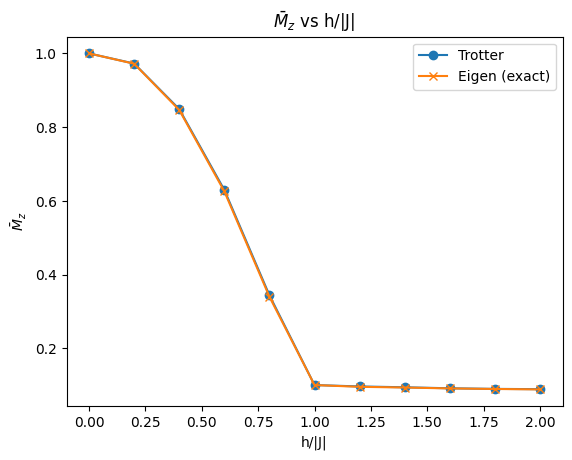

In [24]:
cfg.NQL = 10

print(cfg)
times = np.arange(0, cfg.timesteps * cfg.deltat, cfg.deltat)
psi0 = initial_state_z_up(cfg.NQL)
for j in range(cfg.NQL):
    mz = build_local_operators(Z,I2,cfg.NQL)
M_eq_trotter = []
M_eq_eigen = []
ratios = []

for cfg.h in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:

    # --- Trotter propagation ---
    psit_trot = propagate_state_classical(cfg, psi0)

    expectation_mz_trot = np.empty((psit_trot.shape[1], cfg.NQL + 2))
    for j in range(len(mz)):
        expectation_mz_trot[:, j] = expectation(psit_trot, mz[j])
    expectation_mz_trot[:, -1] = np.arange(cfg.timesteps)
    expectation_mz_trot[:, -2] = np.mean(expectation_mz_trot[:, :-2], axis=1)
    M_eq_trotter.append(np.mean(np.abs(expectation_mz_trot[:, -2])))

    # --- Exact (eigendecomposition) propagation ---
    H = transverse_field_ising(cfg.NQL, cfg.J, cfg.h)
    psit_eigen = exact_eigen(H, psi0, times)

    expectation_mz_eigen = np.empty((psit_eigen.shape[1], cfg.NQL + 2))
    for j in range(len(mz)):
        expectation_mz_eigen[:, j] = expectation(psit_eigen, mz[j])
    expectation_mz_eigen[:, -1] = np.arange(cfg.timesteps)
    expectation_mz_eigen[:, -2] = np.mean(expectation_mz_eigen[:, :-2], axis=1)
    M_eq_eigen.append(np.mean(np.abs(expectation_mz_eigen[:, -2])))

    ratios.append(abs(cfg.h / cfg.J))

print("Trotter:", M_eq_trotter)
print("Eigen:  ", M_eq_eigen)
print("Ratios: ", ratios)

plt.plot(ratios, M_eq_trotter, marker='o', label='Trotter')
plt.plot(ratios, M_eq_eigen, marker='x', label='Eigen (exact)')
plt.xlabel('h/|J|')
plt.ylabel(r'$\bar{M}_{z}$')
plt.title(r'$\bar{M}_{z}$ vs h/|J|')
plt.legend()

Final Check for Trotter vs Eigen decomposition

In [5]:
cfg.NQL = 10

print(cfg)
times = np.arange(0, cfg.timesteps * cfg.deltat, cfg.deltat)
psi0 = initial_state_z_up(cfg.NQL)
for j in range(cfg.NQL):
    mz = build_local_operators(Z,I2,cfg.NQL)

ratios = []

Config(debug=False, n=16, k=12, d=1, l=2, lp=1, coupling=True, periodic=False, full=False, NQL=10, CartPdt=True, model='transverse', timesteps=100, deltat=0.1, J=-1.0, h=2.0)


In [6]:
M_eq_trotter = []

for cfg.h in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:

    # --- Trotter propagation ---
    psit_trot = propagate_state_classical(cfg, psi0)

    expectation_mz_trot = np.empty((psit_trot.shape[1], cfg.NQL + 2))
    for j in range(len(mz)):
        expectation_mz_trot[:, j] = expectation(psit_trot, mz[j])
    expectation_mz_trot[:, -1] = np.arange(cfg.timesteps)
    expectation_mz_trot[:, -2] = np.mean(expectation_mz_trot[:, :-2], axis=1)
    M_eq_trotter.append(np.mean(np.abs(expectation_mz_trot[:, -2])))

    ratios.append(abs(cfg.h / cfg.J))

print("Trotter:", M_eq_trotter)
print("Ratios: ", ratios)

Trotter: [1.0000000000000144, 0.9725150202322971, 0.8489667355666186, 0.6298758310648743, 0.34420593977088787, 0.10081366788741356, 0.09701507182935216, 0.09475120142328083, 0.09203634246132593, 0.09041374557220613, 0.08963636449993002]
Ratios:  [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]


In [8]:
M_eq_eigen = []

for cfg.h in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:

    # --- Exact (eigendecomposition) propagation ---
    H = transverse_field_ising(cfg.NQL, cfg.J, cfg.h)
    psit_eigen = exact_eigen(H, psi0, times)

    expectation_mz_eigen = np.empty((psit_eigen.shape[1], cfg.NQL + 2))
    for j in range(len(mz)):
        expectation_mz_eigen[:, j] = expectation(psit_eigen, mz[j])
    expectation_mz_eigen[:, -1] = np.arange(cfg.timesteps)
    expectation_mz_eigen[:, -2] = np.mean(expectation_mz_eigen[:, :-2], axis=1)
    M_eq_eigen.append(np.mean(np.abs(expectation_mz_eigen[:, -2])))


print("Eigen:  ", M_eq_eigen)

Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Using exact diagonalization. (1024, 1024) (1024,)
Eigen:   [1.0, 0.9720255192016242, 0.8466998661270773, 0.6260431232400077, 0.3402949832454436, 0.10078651877329989, 0.09603490138851065, 0.09411689667890846, 0.09164620406763141, 0.09016799920477254, 0.08895363114924373]


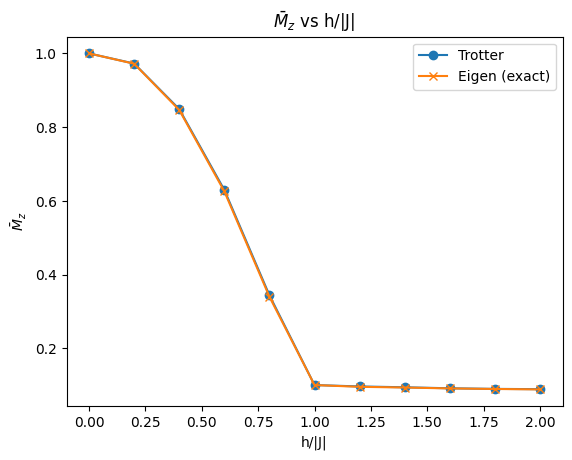

In [9]:
plt.plot(ratios, M_eq_trotter, marker='o', label='Trotter')
plt.plot(ratios, M_eq_eigen, marker='x', label='Eigen (exact)')
plt.xlabel('h/|J|')
plt.ylabel(r'$\bar{M}_{z}$')
plt.title(r'$\bar{M}_{z}$ vs h/|J|')
plt.legend()

In [15]:
np.savetxt('Mz_ratios_eigen_trotter_NQL10_dt0.1_ts100.txt',[ratios,M_eq_eigen,M_eq_trotter])